<a href="https://colab.research.google.com/github/Tanwi20024/student-data-analysis/blob/main/student_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Optional: Upload your own CSV file
from google.colab import files

uploaded = files.upload()  # A button will appear to upload any CSV file

import io
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print("✅ Your file loaded successfully!")
print(df.head())

In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [2]:
# Step 2: Create the dataset and save it as a CSV file
import io

data = """Name,Age,Gender,Math_Score,Science_Score,English_Score,Attendance,Study_Hours
Alice,18,Female,88,92,85,95,6
Bob,17,Male,72,68,74,88,4
Charlie,18,Male,95,89,91,98,8
Diana,17,Female,65,70,80,75,3
Eve,19,Female,78,82,76,90,5
Frank,18,Male,55,60,62,70,2
Grace,17,Female,91,94,89,97,7
Henry,19,Male,80,75,78,85,5
Isla,18,Female,70,73,85,80,4
Jack,17,Male,60,65,58,72,3
Karen,19,Female,85,88,90,93,6
Leo,18,Male,74,70,72,82,4
Mia,17,Female,92,95,88,99,8
Noah,18,Male,68,72,65,78,3
Olivia,19,Female,87,84,91,94,7"""

# Save as CSV file
with open("student_data.csv", "w") as f:
    f.write(data)

# Load it using Pandas
df = pd.read_csv(io.StringIO(data))

print("✅ Dataset created and loaded!")
print(f"   Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
print("\n🔍 First 5 rows:")
print(df.head())

✅ Dataset created and loaded!
   Rows: 15  |  Columns: 8

🔍 First 5 rows:
      Name  Age  Gender  Math_Score  Science_Score  English_Score  Attendance  \
0    Alice   18  Female          88             92             85          95   
1      Bob   17    Male          72             68             74          88   
2  Charlie   18    Male          95             89             91          98   
3    Diana   17  Female          65             70             80          75   
4      Eve   19  Female          78             82             76          90   

   Study_Hours  
0            6  
1            4  
2            8  
3            3  
4            5  


In [3]:
# Step 3: Explore the dataset

# Shape of the dataset
print("📐 Shape of Dataset:")
print(f"   {df.shape[0]} rows and {df.shape[1]} columns")

# Column names
print("\n📋 Column Names:")
print(df.columns.tolist())

# Data types
print("\n🔠 Data Types:")
print(df.dtypes)

# Check for missing values
print("\n❓ Missing Values:")
print(df.isnull().sum())

# Basic statistics
print("\n📊 Basic Statistics:")
print(df.describe())

📐 Shape of Dataset:
   15 rows and 8 columns

📋 Column Names:
['Name', 'Age', 'Gender', 'Math_Score', 'Science_Score', 'English_Score', 'Attendance', 'Study_Hours']

🔠 Data Types:
Name             object
Age               int64
Gender           object
Math_Score        int64
Science_Score     int64
English_Score     int64
Attendance        int64
Study_Hours       int64
dtype: object

❓ Missing Values:
Name             0
Age              0
Gender           0
Math_Score       0
Science_Score    0
English_Score    0
Attendance       0
Study_Hours      0
dtype: int64

📊 Basic Statistics:
             Age  Math_Score  Science_Score  English_Score  Attendance  \
count  15.000000   15.000000      15.000000      15.000000   15.000000   
mean   17.933333   77.333333      78.466667      78.933333   86.400000   
std     0.798809   12.303697      11.344392      10.931388    9.767292   
min    17.000000   55.000000      60.000000      58.000000   70.000000   
25%    17.000000   69.000000      70.00

In [4]:
# Step 4: Calculate Averages

# Average of each score column
print("📊 Average Scores:")
print(f"   Math Score    : {df['Math_Score'].mean():.2f}")
print(f"   Science Score : {df['Science_Score'].mean():.2f}")
print(f"   English Score : {df['English_Score'].mean():.2f}")

# Average attendance and study hours
print(f"\n   Attendance    : {df['Attendance'].mean():.2f}%")
print(f"   Study Hours   : {df['Study_Hours'].mean():.2f} hrs/day")

# Add a new column - Average Score for each student
df['Avg_Score'] = df[['Math_Score', 'Science_Score', 'English_Score']].mean(axis=1)

print("\n🏆 Each Student's Average Score:")
print(df[['Name', 'Math_Score', 'Science_Score', 'English_Score', 'Avg_Score']])

# Top performer
top = df.loc[df['Avg_Score'].idxmax()]
print(f"\n🥇 Top Performer: {top['Name']} with {top['Avg_Score']:.2f} average!")

📊 Average Scores:
   Math Score    : 77.33
   Science Score : 78.47
   English Score : 78.93

   Attendance    : 86.40%
   Study Hours   : 5.00 hrs/day

🏆 Each Student's Average Score:
       Name  Math_Score  Science_Score  English_Score  Avg_Score
0     Alice          88             92             85  88.333333
1       Bob          72             68             74  71.333333
2   Charlie          95             89             91  91.666667
3     Diana          65             70             80  71.666667
4       Eve          78             82             76  78.666667
5     Frank          55             60             62  59.000000
6     Grace          91             94             89  91.333333
7     Henry          80             75             78  77.666667
8      Isla          70             73             85  76.000000
9      Jack          60             65             58  61.000000
10    Karen          85             88             90  87.666667
11      Leo          74            

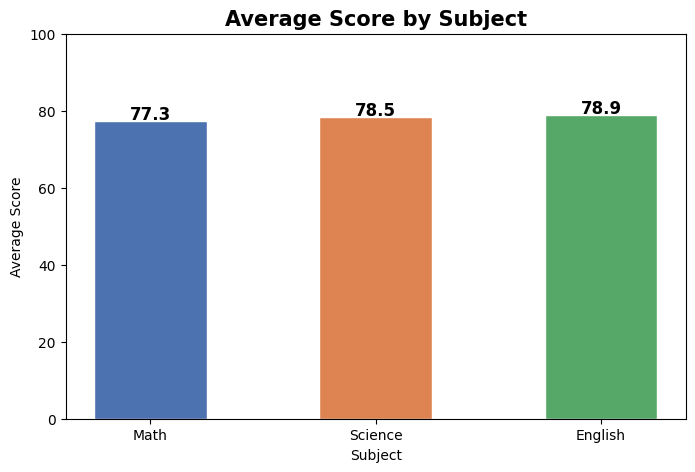

✅ Bar Chart created successfully!


In [5]:
# Step 5: Bar Chart - Average Score by Subject

avg_scores = [df['Math_Score'].mean(),
              df['Science_Score'].mean(),
              df['English_Score'].mean()]

subjects = ['Math', 'Science', 'English']
colors = ['#4C72B0', '#DD8452', '#55A868']

plt.figure(figsize=(8, 5))
bars = plt.bar(subjects, avg_scores, color=colors, width=0.5, edgecolor='white')

# Add value labels on top of each bar
for bar, val in zip(bars, avg_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}',
             ha='center', fontsize=12, fontweight='bold')

plt.title('Average Score by Subject', fontsize=15, fontweight='bold')
plt.ylabel('Average Score')
plt.xlabel('Subject')
plt.ylim(0, 100)
plt.show()

print("✅ Bar Chart created successfully!")

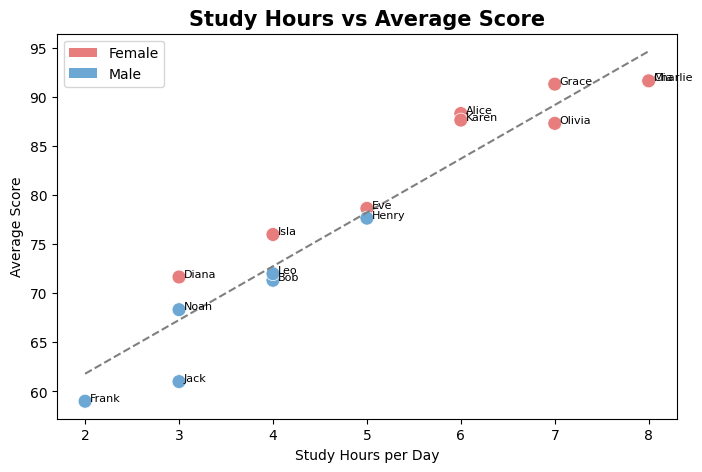

✅ Scatter Plot created successfully!


In [6]:
# Step 6: Scatter Plot - Study Hours vs Average Score

plt.figure(figsize=(8, 5))

# Different colors for Male and Female
colors = ['#E87D7D' if g == 'Female' else '#6DA8D4' for g in df['Gender']]

plt.scatter(df['Study_Hours'], df['Avg_Score'],
            c=colors, s=100, edgecolors='white', linewidth=0.5)

# Add student names next to each dot
for i, row in df.iterrows():
    plt.text(row['Study_Hours'] + 0.05, row['Avg_Score'],
             row['Name'], fontsize=8)

# Add trend line
z = np.polyfit(df['Study_Hours'], df['Avg_Score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Study_Hours'].min(), df['Study_Hours'].max(), 100)
plt.plot(x_line, p(x_line), '--', color='gray', linewidth=1.5, label='Trend Line')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E87D7D', label='Female'),
                   Patch(facecolor='#6DA8D4', label='Male')]
plt.legend(handles=legend_elements)

plt.title('Study Hours vs Average Score', fontsize=15, fontweight='bold')
plt.xlabel('Study Hours per Day')
plt.ylabel('Average Score')
plt.show()

print("✅ Scatter Plot created successfully!")

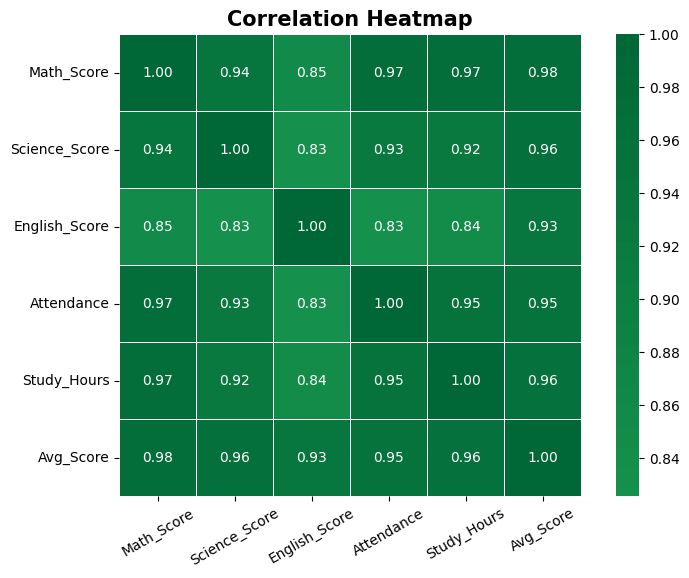

✅ Heatmap created successfully!


In [7]:
# Step 7: Heatmap - Correlation Between All Variables

# Select only numeric columns
numeric_cols = ['Math_Score', 'Science_Score', 'English_Score',
                'Attendance', 'Study_Hours', 'Avg_Score']

# Calculate correlation
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 6))

sns.heatmap(corr_matrix,
            annot=True,        # show numbers inside boxes
            fmt='.2f',         # round to 2 decimal places
            cmap='RdYlGn',     # Red -> Yellow -> Green color scheme
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap', fontsize=15, fontweight='bold')
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.show()

print("✅ Heatmap created successfully!")

In [8]:
# Step 8: Key Insights & Observations

print("=" * 50)
print("      KEY INSIGHTS & OBSERVATIONS")
print("=" * 50)

# 1. Best and worst subject
avg_math    = df['Math_Score'].mean()
avg_science = df['Science_Score'].mean()
avg_english = df['English_Score'].mean()

best    = max([('Math', avg_math), ('Science', avg_science), ('English', avg_english)], key=lambda x: x[1])
weakest = min([('Math', avg_math), ('Science', avg_science), ('English', avg_english)], key=lambda x: x[1])

print(f"\n📚 Subject Performance:")
print(f"   Best Subject   : {best[0]} ({best[1]:.2f} avg)")
print(f"   Weakest Subject: {weakest[0]} ({weakest[1]:.2f} avg)")

# 2. Study hours impact
corr_study = df['Study_Hours'].corr(df['Avg_Score'])
print(f"\n📖 Study Hours Impact:")
print(f"   Correlation with Avg Score : {corr_study:.2f}")
print(f"   Conclusion : More study hours = Higher scores!")

# 3. Attendance impact
corr_attend = df['Attendance'].corr(df['Avg_Score'])
print(f"\n🎓 Attendance Impact:")
print(f"   Correlation with Avg Score : {corr_attend:.2f}")
print(f"   Conclusion : Better attendance = Better performance!")

# 4. Top and bottom performers
top    = df.loc[df['Avg_Score'].idxmax()]
bottom = df.loc[df['Avg_Score'].idxmin()]
print(f"\n🏆 Top Performer:")
print(f"   {top['Name']} with average score of {top['Avg_Score']:.2f}")
print(f"\n📉 Needs Improvement:")
print(f"   {bottom['Name']} with average score of {bottom['Avg_Score']:.2f}")

# 5. Gender wise average
female_avg = df[df['Gender'] == 'Female']['Avg_Score'].mean()
male_avg   = df[df['Gender'] == 'Male']['Avg_Score'].mean()
print(f"\n👥 Gender wise Average Score:")
print(f"   Female : {female_avg:.2f}")
print(f"   Male   : {male_avg:.2f}")

print("\n" + "=" * 50)
print("✅ Analysis Complete! Great Work!")
print("=" * 50)

      KEY INSIGHTS & OBSERVATIONS

📚 Subject Performance:
   Best Subject   : English (78.93 avg)
   Weakest Subject: Math (77.33 avg)

📖 Study Hours Impact:
   Correlation with Avg Score : 0.96
   Conclusion : More study hours = Higher scores!

🎓 Attendance Impact:
   Correlation with Avg Score : 0.95
   Conclusion : Better attendance = Better performance!

🏆 Top Performer:
   Charlie with average score of 91.67

📉 Needs Improvement:
   Frank with average score of 59.00

👥 Gender wise Average Score:
   Female : 84.08
   Male   : 71.57

✅ Analysis Complete! Great Work!
